# Pattern Recognition

Daffa M. Siddiq -- 24/533358/PA/22569

Pengenalan Pola (KOM) -- Assignment 2

<br>

---

<br>

Upload Audio File

In [ ]:
from google.colab import files
uploaded = files.upload()   # Select test.m4a from your computer

Saving test.m4a to test.m4a


<br>

---

<br>

Convert .m4a to .wav using ffmpeg

In [ ]:
import os

# Assume uploaded file is named 'test.m4a'
input_file = 'test.m4a'
output_file = 'test.wav'

# Convert using ffmpeg (installed in Colab by default)
!ffmpeg -i {input_file} -acodec pcm_s16le -ar 16000 -ac 1 {output_file}

print(f"Converted to {output_file}")

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

<br>

---

<br>

Read .wav to read header and ```array``` to get raw samples

In [ ]:
import wave
import array

def read_wav(filename):
    with wave.open(filename, 'rb') as wav:
        # Get parameters
        nchannels = wav.getnchannels()
        sampwidth = wav.getsampwidth()
        framerate = wav.getframerate()
        nframes = wav.getnframes()
        print(f"Channels: {nchannels}, Sample width: {sampwidth} bytes, "
              f"Sample rate: {framerate} Hz, Frames: {nframes}")

        # Read raw frames as bytes
        frames = wav.readframes(nframes)
        # Convert to array of ints (assuming 16‑bit PCM, mono)
        if sampwidth == 2:
            fmt = 'h'  # signed short
        else:
            raise ValueError("Only 16‑bit PCM supported.")
        samples = array.array(fmt, frames)
        # Normalize to floats in range [-1, 1]
        samples = [s / 32768.0 for s in samples]
    return samples, framerate

signal, fs = read_wav(output_file)
print(f"Loaded {len(signal)} samples.")

Channels: 1, Sample width: 2 bytes, Sample rate: 16000 Hz, Frames: 74752
Loaded 74752 samples.


<br>

---

<br>

Frame the signal

In [ ]:
frame_size = int(0.025 * fs)   # 25 ms
hop_size = int(0.010 * fs)     # 10 ms

def frame_signal(signal, frame_size, hop_size):
    frames = []
    for start in range(0, len(signal) - frame_size + 1, hop_size):
        frames.append(signal[start:start+frame_size])
    return frames

frames = frame_signal(signal, frame_size, hop_size)
print(f"Number of frames: {len(frames)}")

Number of frames: 465


<br>

---

<br>

Feature Extraction Functions

In [ ]:
# ---------- Energy ----------
def energy(frame):
    """Mean of squares."""
    sum_sq = 0.0
    for x in frame:
        sum_sq += x * x
    return sum_sq / len(frame)

# ---------- Zero Crossing Rate ----------
def zcr(frame):
    """Fraction of sign changes."""
    n = len(frame)
    if n < 2:
        return 0.0
    crossings = 0
    for i in range(1, n):
        prev = frame[i-1]
        curr = frame[i]
        if (prev >= 0 and curr < 0) or (prev < 0 and curr >= 0):
            crossings += 1
    return crossings / n

# ---------- Natural logarithm (Taylor approximation) ----------
def ln(x):
    if x <= 0:
        return 0.0
    e = 2.718281828459045
    n = 0
    while x > e:
        x /= e
        n += 1
    while x < 1/e:
        x *= e
        n -= 1
    y = x - 1
    term = y
    result = 0.0
    k = 1
    while k <= 10:
        if k % 2 == 1:
            result += term / k
        else:
            result -= term / k
        term *= y
        k += 1
    return result + n

def log2(x):
    return ln(x) / ln(2) if x > 0 else 0

# ---------- Energy Entropy ----------
def energy_entropy(frame, num_sub=10):
    sub_len = len(frame) // num_sub
    sub_energies = []
    for i in range(num_sub):
        start = i * sub_len
        end = start + sub_len if i < num_sub-1 else len(frame)
        sub = frame[start:end]
        e = sum(x*x for x in sub)
        sub_energies.append(e)
    total = sum(sub_energies)
    if total == 0:
        return 0.0
    ent = 0.0
    for e in sub_energies:
        p = e / total
        if p > 0:
            ent -= p * log2(p)
    return ent

<br>

---

<br>

Compute Features for All Frames

In [ ]:
energy_list = []
zcr_list = []
entropy_list = []

for f in frames:
    energy_list.append(energy(f))
    zcr_list.append(zcr(f))
    entropy_list.append(energy_entropy(f))

print(f"Energy: {len(energy_list)} values, range [{min(energy_list):.4f}, {max(energy_list):.4f}]")
print(f"ZCR: {len(zcr_list)} values, range [{min(zcr_list):.4f}, {max(zcr_list):.4f}]")
print(f"Entropy: {len(entropy_list)} values, range [{min(entropy_list):.4f}, {max(entropy_list):.4f}]")

Energy: 465 values, range [0.0000, 0.0010]
ZCR: 465 values, range [0.0000, 0.6875]
Entropy: 465 values, range [0.0000, 3.5484]


<br>

---

<br>

Histogram Function

In [ ]:
def histogram(data, num_bins=20):
    min_val = min(data)
    max_val = max(data)
    if min_val == max_val:
        return [len(data)], [min_val, max_val]
    bin_width = (max_val - min_val) / num_bins
    counts = [0] * num_bins
    edges = [min_val + i * bin_width for i in range(num_bins+1)]
    for val in data:
        if val == max_val:
            idx = num_bins - 1
        else:
            idx = int((val - min_val) / bin_width)
        counts[idx] += 1
    return counts, edges

# Compute histograms (we'll store them, not just print)
e_counts, e_edges = histogram(energy_list, num_bins=20)
z_counts, z_edges = histogram(zcr_list, num_bins=20)
ent_counts, ent_edges = histogram(entropy_list, num_bins=20)

print("Energy histogram counts:", e_counts)
print("ZCR histogram counts:", z_counts)
print("Entropy histogram counts:", ent_counts)

Energy histogram counts: [282, 29, 30, 20, 29, 15, 7, 12, 10, 4, 8, 5, 5, 2, 2, 2, 0, 2, 0, 1]
ZCR histogram counts: [122, 249, 43, 6, 6, 5, 8, 4, 2, 4, 2, 0, 1, 2, 3, 0, 1, 3, 0, 4]
Entropy histogram counts: [3, 0, 0, 0, 1, 0, 1, 0, 2, 1, 2, 4, 6, 5, 21, 35, 80, 135, 132, 37]


<br>

---

<br>

Plot Histograms

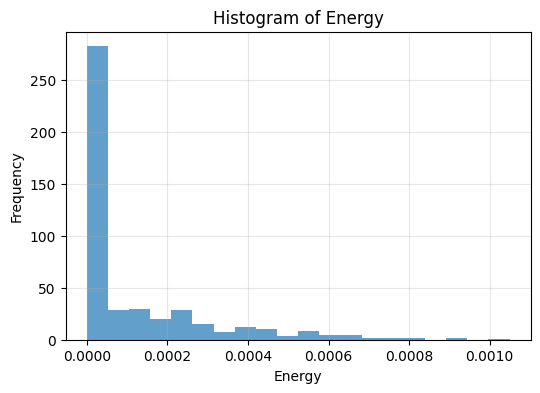

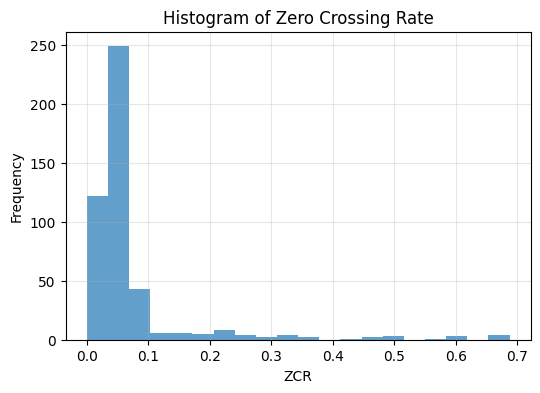

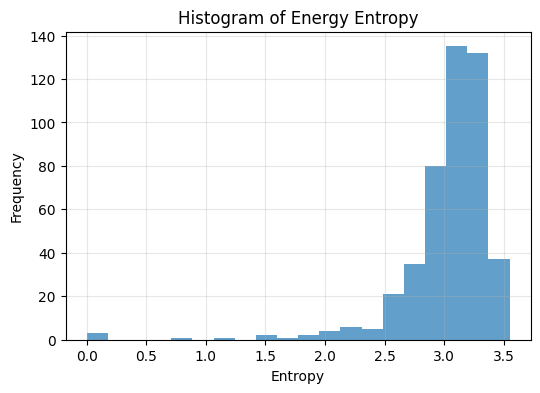

In [ ]:
import matplotlib.pyplot as plt

def plot_hist(counts, edges, title, xlabel):
    plt.figure(figsize=(6,4))
    plt.bar(edges[:-1], counts, width=edges[1]-edges[0], align='edge', alpha=0.7)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    plt.show()

plot_hist(e_counts, e_edges, 'Histogram of Energy', 'Energy')
plot_hist(z_counts, z_edges, 'Histogram of Zero Crossing Rate', 'ZCR')
plot_hist(ent_counts, ent_edges, 'Histogram of Energy Entropy', 'Entropy')